In [1]:
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import pandas as pd
import colorsys

In [2]:
# (((xref:interpro-IPR016054 OR xref:interpro-IPR026110 OR xref:interpro-IPR026524 OR xref:interpro-IPR031424 OR xref:interpro-IPR038773 OR xref:interpro-IPR039457 OR xref:interpro-IPR039237 OR xref:interpro-IPR042339 OR xref:interpro-IPR051445 OR xref:interpro-IPR035076 OR xref:interpro-IPR003571 OR xref:interpro-IPR045860) AND fragment:false) OR (accession:I6R1R5 OR accession:P0DPX5 OR accession:P0DPX9 OR accession:P0DPY0 OR accession:P0DPY1 OR accession:P0DPX7 OR accession:P0DPX8 OR accession:P0DPX6 OR accession:P0DPU8)) AND (taxonomy_id:33208)

In [26]:
df = pd.read_csv("../../data/raw/data_for_tree/clusters_70id_reassign.tsv", sep='\t', header=None, names=["rep", "member"])
df["protein_id"] = np.where(
    df["member"].str.contains("Centipede", case=False, na=False),
    df["member"],
    df["member"].str.split("_").str[0]
)
df

,rep,member,protein_id
0,Centipede3FTx_0001_61981,Centipede3FTx_0001_61981,Centipede3FTx_0001_61981
1,Centipede3FTx_0033_61981,Centipede3FTx_0033_61981,Centipede3FTx_0033_61981
2,Centipede3FTx_0097_984703,Centipede3FTx_0097_984703,Centipede3FTx_0097_984703
3,A0A7J7F872_IPR042339_1_14-139,A0A7J7F872_IPR042339_1_14-139,A0A7J7F872
4,A0AAD4U641_IPR016054_2_166-237,A0AAD4U641_IPR016054_2_166-237,A0AAD4U641
...,...,...,...
58182,P0DPX5_IPR045860_1_24-107,I6R1R5_IPR045860_1_24-110,I6R1R5
58183,P0DPX5_IPR045860_1_24-107,I6RA69_IPR045860_1_24-110,I6RA69
58184,Q8T8C6_IPR045860_1_13-112,Q8T8C6_IPR045860_1_13-112,Q8T8C6
58185,R7UXY0_IPR045860_1_94-150,R7UXY0_IPR045860_1_94-150,R7UXY0


In [40]:
df[df["member"].str.split("_").str[0] == "A0A9D1E7W6"]

,rep,member,protein_id


In [50]:
from Bio import SeqIO

# --- Normalization function ---
def normalize_id(seq_id: str) -> str:
    if "Centipede" in seq_id:
        return seq_id
    return seq_id.split("_")[0]

def normalize_id_uniprotfasta(seq_id: str) -> str:
    if "Centipede" in seq_id:
        return seq_id
    return seq_id.split("|")[1]
# --- 1. FASTA used for clustering --- (based on data for clustering)
fasta1_file = "/Users/selin/PycharmProjects/3FTx_novel_taxa/data/interm/merged/dataset_for_cluster.fasta"
fasta1_ids = {normalize_id(rec.id) for rec in SeqIO.parse(fasta1_file, "fasta")}
print(f"FASTA1 (cluster input) IDs: {len(fasta1_ids)}")

# --- 2. Cluster TSV members --- (based on data for clustering)
member_ids = {normalize_id(m) for m in df["member"].astype(str)}
print(f"Cluster TSV member IDs: {len(member_ids)}")

# --- 3. Metadata --- (merged from interpro directories)
metadata = pd.read_csv("../../data/interm/merged/merged_with_lineage.csv")
metadata_ids = set(metadata["protein_id"].astype(str))
print(f"Metadata protein IDs: {len(metadata_ids)}")

# --- 4. Second FASTA  --- (merged from interpro directories)
fasta2_file = "../../data/interm/merged/sequences.fasta"
fasta2_ids = {normalize_id_uniprotfasta(rec.id) for rec in SeqIO.parse(fasta2_file, "fasta")}
print(f"FASTA2 (sequences.fasta) IDs: {len(fasta2_ids)}")

# --- Pairwise comparisons ---
def compare_sets(name_a, ids_a, name_b, ids_b, n=10):
    extra = ids_a - ids_b
    missing = ids_b - ids_a
    print(f"\n### {name_a} vs {name_b} ###")
    print(f"Extra in {name_a} but not in {name_b}: {len(extra)}")
    print(f"Extra in {name_b} but not in {name_a}: {len(missing)}")
    if extra:
        print("Examples extra:", list(extra)[:n])
    if missing:
        print("Examples missing:", list(missing)[:n])

#compare_sets("FASTA1", fasta1_ids, "TSV", member_ids)
compare_sets("FASTA1", fasta1_ids, "Metadata", metadata_ids)
#compare_sets("FASTA1", fasta1_ids, "FASTA2", fasta2_ids)
#compare_sets("TSV", member_ids, "Metadata", metadata_ids)
#compare_sets("TSV", member_ids, "FASTA2", fasta2_ids)
#compare_sets("Metadata", metadata_ids, "FASTA2", fasta2_ids)


FASTA1 (cluster input) IDs: 52067
Cluster TSV member IDs: 52067
Metadata protein IDs: 52829
FASTA2 (sequences.fasta) IDs: 52829

### FASTA1 vs Metadata ###
Extra in FASTA1 but not in Metadata: 148
Extra in Metadata but not in FASTA1: 910
Examples extra: ['Centipede3FTx_0033_61981', 'Centipede3FTx_0092_984703', 'Centipede3FTx_0115_984703', 'Centipede3FTx_0080_61981', 'Centipede3FTx_0036_60158', 'Centipede3FTx_0123_60158', 'Centipede3FTx_0001_61981', 'Centipede3FTx_0126_60158', 'Centipede3FTx_0013_1255758', 'Centipede3FTx_0140_1255758']
Examples missing: ['A0A182TW55', 'A0A151X230', 'A0A2K5NXF1', 'A0A087QQZ9', 'Q6PBG1', 'A0A9J7H3G5', 'A0A836EPP3', 'A0AAD5B061', 'A0A8C6W3Y0', 'A0A852ARA8']


In [4]:
rep_to_cluster = {rep: i for i, rep in enumerate(sorted(df["rep"].unique()))}
df["cluster_id"] = df["rep"].map(rep_to_cluster)
df

,rep,member,protein_id,cluster_id
0,Centipede3FTx_0001_61981,Centipede3FTx_0001_61981,Centipede3FTx_0001_61981,11103
1,Centipede3FTx_0033_61981,Centipede3FTx_0033_61981,Centipede3FTx_0033_61981,11130
2,Centipede3FTx_0097_984703,Centipede3FTx_0097_984703,Centipede3FTx_0097_984703,11180
3,A0A7J7F872_IPR042339_1_14-139,A0A7J7F872_IPR042339_1_14-139,A0A7J7F872,4329
4,A0AAD4U641_IPR016054_2_166-237,A0AAD4U641_IPR016054_2_166-237,A0AAD4U641,8912
...,...,...,...,...
58182,P0DPX5_IPR045860_1_24-107,I6R1R5_IPR045860_1_24-110,I6R1R5,11708
58183,P0DPX5_IPR045860_1_24-107,I6RA69_IPR045860_1_24-110,I6RA69,11708
58184,Q8T8C6_IPR045860_1_13-112,Q8T8C6_IPR045860_1_13-112,Q8T8C6,11854
58185,R7UXY0_IPR045860_1_94-150,R7UXY0_IPR045860_1_94-150,R7UXY0,11951


In [5]:
# Count how many members each cluster has
df["cluster_id"].value_counts()

cluster_id
5469     1337
2351      830
1690      681
11454     665
8573      653
         ... 
1508        1
11728       1
11523       1
11244       1
12028       1
Name: count, Length: 12188, dtype: int64

In [18]:
metadata = pd.read_csv("../../data/interm/merged/merged_with_lineage.csv")
metadata

,protein_id,protein_name,organism,sequence_length,tax_id,interpro_1,interpro_2,interpro_3,interpro_4,kingdom,phylum,class,order,family,genus
0,A0A016RUD2,Activin types I and II receptor domain-contain...,Ancylostoma ceylanicum,102,53326.0,IPR045860,NaN,NaN,NaN,Metazoa,Nematoda,Chromadorea,Rhabditida,Ancylostomatidae,Ancylostoma
1,A0A016SEB0,UPAR/Ly6 domain-containing protein qvr,Ancylostoma ceylanicum,160,53326.0,IPR031424,NaN,NaN,NaN,Metazoa,Nematoda,Chromadorea,Rhabditida,Ancylostomatidae,Ancylostoma
2,A0A016SHP2,Protein quiver,Ancylostoma ceylanicum,171,53326.0,IPR031424,NaN,NaN,NaN,Metazoa,Nematoda,Chromadorea,Rhabditida,Ancylostomatidae,Ancylostoma
3,A0A016SK76,UPAR/Ly6 domain-containing protein,Ancylostoma ceylanicum,685,53326.0,IPR045860,NaN,NaN,NaN,Metazoa,Nematoda,Chromadorea,Rhabditida,Ancylostomatidae,Ancylostoma
4,A0A016SKC5,Mos1 transposase HTH domain-containing protein,Ancylostoma ceylanicum,755,53326.0,IPR045860,NaN,NaN,NaN,Metazoa,Nematoda,Chromadorea,Rhabditida,Ancylostomatidae,Ancylostoma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52824,X1WGJ5,UPAR/Ly6 domain-containing protein,Danio rerio (Zebrafish),126,7955.0,IPR016054,IPR045860,NaN,NaN,Metazoa,Chordata,Actinopteri,Cypriniformes,Danionidae,Danio
52825,X1YV74,Serine/threonine-protein kinase receptor,Capitella teleta,488,283909.0,IPR045860,NaN,NaN,NaN,Metazoa,Annelida,Polychaeta,NaN,Capitellidae,Capitella
52826,X2ACF0,Protein sleepless,Capitella teleta (Polychaete worm),106,283909.0,IPR031424,NaN,NaN,NaN,Metazoa,Annelida,Polychaeta,NaN,Capitellidae,Capitella
52827,X2ATT7,Snake toxin/toxin-like domain-containing protein,Capitella teleta,157,283909.0,IPR045860,NaN,NaN,NaN,Metazoa,Annelida,Polychaeta,NaN,Capitellidae,Capitella


In [21]:
metadata["kingdom"].value_counts()

kingdom
Metazoa           52788
Viridiplantae        10
Heunggongvirae        4
Bacillati             2
Name: count, dtype: int64

In [7]:
# Initialize an empty list to store results
merged_list = []

for _, row in df.iterrows():
    member = row['member']
    # Find all metadata rows where identifier is substring of member
    matches = metadata[metadata['protein_id'].apply(lambda x: x in member)].copy()
    if matches.empty:
        # If no match, keep the df row with NaNs for metadata columns
        merged_list.append({**row})
    else:
        for _, m_row in matches.iterrows():
            merged_list.append({**row, **m_row.to_dict()})

df_merged = pd.DataFrame(merged_list)

# Reorder columns: member, cluster_id first
cols = ['member','cluster_id'] + [c for c in df_merged.columns if c not in ['member','cluster_id']]
df_merged = df_merged[cols]

In [8]:
df_merged["cluster_id"].value_counts()

cluster_id
5469     1337
2351      830
1690      681
11454     665
8573      653
         ... 
1508        1
11728       1
11523       1
11244       1
12028       1
Name: count, Length: 12188, dtype: int64

In [9]:
df_merged

,member,cluster_id,rep,protein_id,protein_name,organism,sequence_length,tax_id,interpro_1,interpro_2,interpro_3,interpro_4,kingdom,phylum,class,order,family,genus
0,Centipede3FTx_0001_61981,11103,Centipede3FTx_0001_61981,Centipede3FTx_0001_61981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Centipede3FTx_0033_61981,11130,Centipede3FTx_0033_61981,Centipede3FTx_0033_61981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Centipede3FTx_0097_984703,11180,Centipede3FTx_0097_984703,Centipede3FTx_0097_984703,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A0A7J7F872_IPR042339_1_14-139,4329,A0A7J7F872_IPR042339_1_14-139,A0A7J7F872,UPAR/Ly6 domain-containing protein,Diceros bicornis minor (South-central black rh...,139.0,77932.0,IPR016054,IPR035076,IPR042339,IPR045860,Metazoa,Chordata,Mammalia,Perissodactyla,Rhinocerotidae,Diceros
4,A0AAD4U641_IPR016054_2_166-237,8912,A0AAD4U641_IPR016054_2_166-237,A0AAD4U641,UPAR/Ly6 domain-containing protein,Ovis ammon polii,401.0,230172.0,IPR016054,IPR035076,IPR042339,IPR045860,Metazoa,Chordata,Mammalia,Artiodactyla,Bovidae,Ovis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58184,I6R1R5_IPR045860_1_24-110,11708,P0DPX5_IPR045860_1_24-107,I6R1R5,Omega-scoloptoxin(05)-Ssm1a,Scolopendra mutilans,129.0,2836329.0,IPR045860,NaN,NaN,NaN,Metazoa,Arthropoda,Chilopoda,Scolopendromorpha,Scolopendridae,Scolopendra
58185,I6RA69_IPR045860_1_24-110,11708,P0DPX5_IPR045860_1_24-107,I6RA69,Putative Ca2+ channel activator,Scolopendra subspinipes,136.0,55038.0,IPR045860,NaN,NaN,NaN,Metazoa,Arthropoda,Chilopoda,Scolopendromorpha,Scolopendridae,Scolopendra
58186,Q8T8C6_IPR045860_1_13-112,11854,Q8T8C6_IPR045860_1_13-112,Q8T8C6,Serine/threonine-protein kinase receptor,Halocynthia roretzi,591.0,7729.0,IPR045860,NaN,NaN,NaN,Metazoa,Chordata,Ascidiacea,Stolidobranchia,Pyuridae,Halocynthia
58187,R7UXY0_IPR045860_1_94-150,11951,R7UXY0_IPR045860_1_94-150,R7UXY0,UPAR/Ly6 domain-containing protein,Capitella teleta,177.0,283909.0,IPR045860,NaN,NaN,NaN,Metazoa,Annelida,Polychaeta,NaN,Capitellidae,Capitella


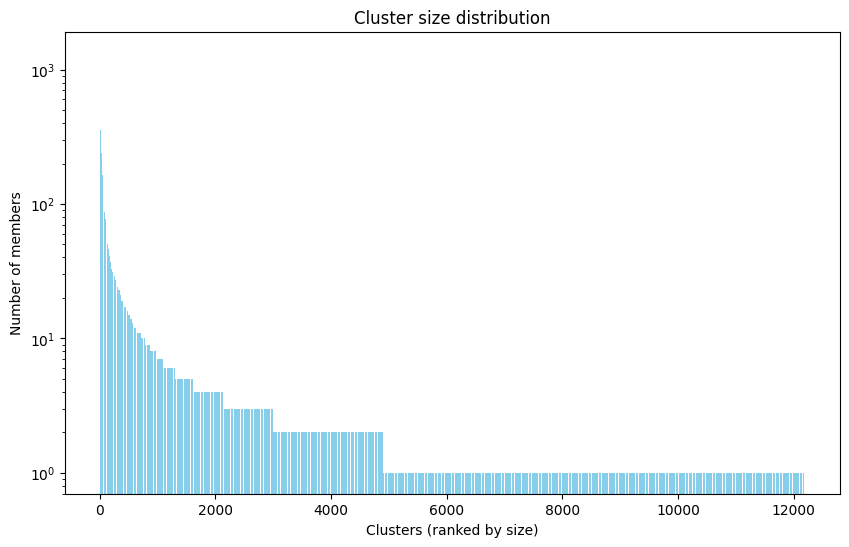

In [10]:
# count members per cluster and sort descending
cluster_sizes = df_merged.groupby("cluster_id")["member"].count().sort_values(ascending=False)

plt.figure(figsize=(10,6))
plt.bar(range(len(cluster_sizes)), cluster_sizes.values, color='skyblue')
plt.xlabel("Clusters (ranked by size)")
plt.ylabel("Number of members")
plt.yscale('log')
plt.title("Cluster size distribution")
plt.show()

In [17]:
df_merged[df_merged['cluster_id'] == 5469].groupby('kingdom').size()


kingdom
Metazoa    1337
dtype: int64

In [12]:
taxonomy_cols = ['kingdom', 'phylum', 'class', 'order', 'family', 'genus']

# Get top 100 clusters by member count
top_clusters = df_merged['cluster_id'].value_counts().head(100).index
df_top = df_merged[df_merged['cluster_id'].isin(top_clusters)]

# Compute homogeneity percentages per cluster
homogeneity_top = {}
for col in taxonomy_cols:
    ct = pd.crosstab(df_top['cluster_id'], df_top[col], normalize='index') * 100
    homogeneity_top[col] = ct.round(1)  # round to 1 decimal

# Example: check top cluster phylum composition
print(homogeneity_top['class'])


class       Actinopteri  Amphibia   Aves  Bivalvia  Chondrichthyes  Cladistia  \
cluster_id                                                                      
105                 0.0       0.0  100.0       0.0             0.0        0.0   
468               100.0       0.0    0.0       0.0             0.0        0.0   
486                 0.0       0.0  100.0       0.0             0.0        0.0   
766               100.0       0.0    0.0       0.0             0.0        0.0   
776               100.0       0.0    0.0       0.0             0.0        0.0   
...                 ...       ...    ...       ...             ...        ...   
11702               0.0       0.0    0.0       0.0             0.0        0.0   
11830               0.0       0.0    0.0       0.0             0.0        0.0   
11891              68.8      12.5   18.8       0.0             0.0        0.0   
12127               0.0       1.0    1.0       0.0             0.0        0.0   
12166              98.2     

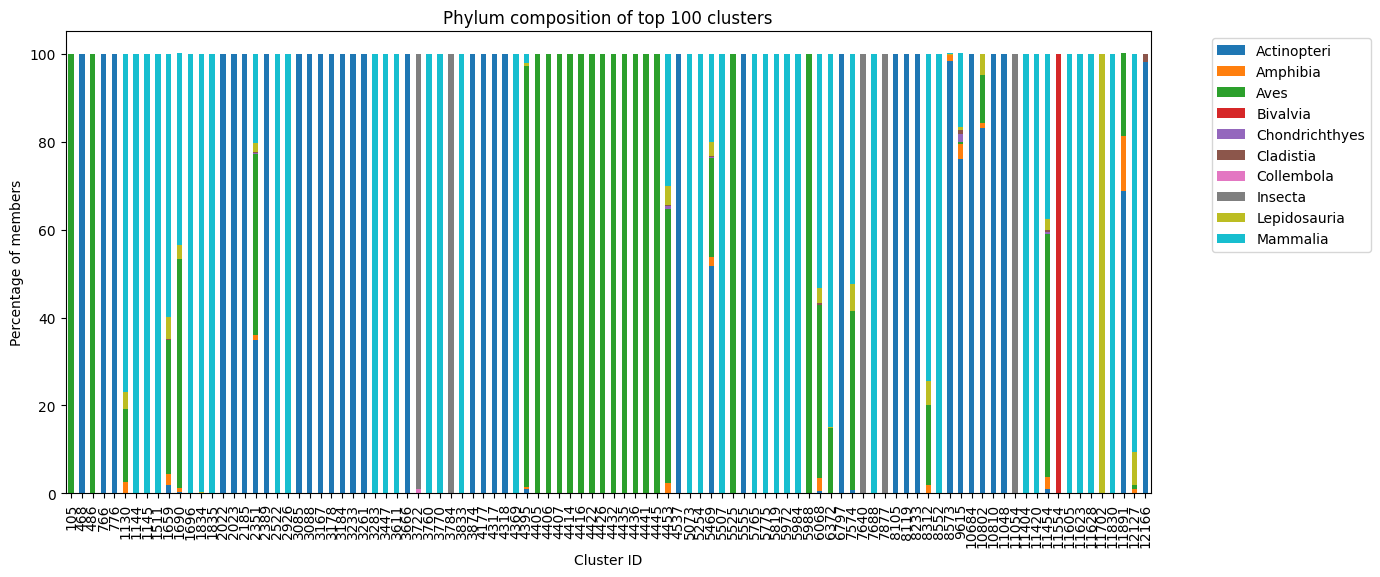

In [13]:
homogeneity_top['class'].plot(kind='bar', stacked=True, figsize=(14,6))
plt.ylabel("Percentage of members")
plt.xlabel("Cluster ID")
plt.title("Phylum composition of top 100 clusters")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

In [22]:
df_merged["kingdom"].value_counts()

kingdom
Metazoa           58006
Viridiplantae         5
Heunggongvirae        4
Name: count, dtype: int64

In [14]:
taxonomy_cols = ['kingdom', 'phylum', 'class', 'order', 'family', 'genus']

# Prepare sunburst/treemap dataframe
sunburst_df = df_merged.groupby(taxonomy_cols + ['cluster_id']).size().reset_index(name='count')
sunburst_df['root'] = 'All clusters'

# Generate maximally distinct colors
def distinct_colors(n, sat=0.8, light=0.6):
    return [f'rgb({int(r*255)},{int(g*255)},{int(b*255)})'
            for i in range(n)
            for r,g,b in [colorsys.hls_to_rgb(i/n, light, sat)]]

cluster_ids = sunburst_df['cluster_id'].unique()
cluster_colors = dict(zip(cluster_ids, distinct_colors(len(cluster_ids), 0.9, 0.5)))

# --- Sunburst with maximally distinct cluster colors ---
px.sunburst(
    sunburst_df,
    path=['root'] + taxonomy_cols + ['cluster_id'],
    values='count',
    color='cluster_id',
    color_discrete_map=cluster_colors,
    title="Taxonomic Distribution with Maximally Distinct Colors"
).update_layout(margin=dict(t=50, l=0, r=0, b=0), width=1200, height=1200, font_size=10).write_html("sunburst_maximally_distinct.html")

In [15]:
# --- Treemap with golden ratio colors ---
golden_colors = {}
golden_ratio = 1.618033988749895
for i, cid in enumerate(cluster_ids):
    hue = (i * golden_ratio * 137.508) % 360
    sat, light = 0.7 + 0.1*(i%3), 0.4 + 0.1*((i+1)%4)
    r, g, b = colorsys.hls_to_rgb(hue/360, light, sat)
    golden_colors[cid] = f'rgb({int(r*255)},{int(g*255)},{int(b*255)})'

px.treemap(
    sunburst_df,
    path=['root'] + taxonomy_cols + ['cluster_id'],
    values='count',
    color='cluster_id',
    color_discrete_map=golden_colors,
    title="Optimized Taxonomic Treemap with Maximum Color Distinction",
    hover_data={col: True for col in taxonomy_cols + ['cluster_id', 'count']}
).update_traces(
    textinfo="label+value+percent root",
    texttemplate="<b>%{label}</b><br>Count: %{value}<br>%{percentRoot:.1%}",
    textfont_size=9,
    textfont_color="white",
    textposition="middle center",
    hovertemplate="<b>%{label}</b><br>Count: %{value}<br>Percent of total: %{percentRoot:.2%}<br><extra></extra>",
    maxdepth=4,
    branchvalues="total"
).update_layout(
    width=1400, height=900,
    margin=dict(t=80, l=20, r=20, b=20),
    title_font_size=16, title_x=0.5,
    font_family="Arial",
    plot_bgcolor='white', paper_bgcolor='white'
).write_html("treemap_optimized.html")

In [16]:
# --- Sunburst colored by phylum_class ---
sunburst_df['color_group'] = sunburst_df['phylum'] + '_' + sunburst_df['class']
group_colors = dict(zip(sunburst_df['color_group'].unique(), distinct_colors(len(sunburst_df['color_group'].unique()))))

px.sunburst(
    sunburst_df,
    path=['root'] + taxonomy_cols + ['cluster_id'],
    values='count',
    color='color_group',
    color_discrete_map=group_colors,
    title="Taxonomic Distribution (Clusters colored by phylum_class)"
).update_layout(margin=dict(t=50, l=0, r=0, b=0), width=1200, height=1200, font_size=10).write_html("sunburst_cluster_count.html")
